#### Setup

In [1]:
# Cell 1: Setup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
# Create charts directory
os.makedirs('../charts', exist_ok=True)
# Load master dataset
df = pd.read_csv('../data/olist_master.csv', low_memory=False)
print(f'Loaded master dataset: {df.shape}')
# Chart style settings
plt.rcParams.update({
 'figure.facecolor': 'white',
 'axes.facecolor': 'white',
 'axes.spines.top': False,
 'axes.spines.right':False,
 'font.family': 'DejaVu Sans',
 'axes.titlesize': 14,
 'axes.titleweight': 'bold',
 'axes.labelsize': 11,
 'xtick.labelsize': 10,
 'ytick.labelsize': 10,
})
BLUE = '#2E75B6'
GREEN = '#1F7A4A'
ORANGE = '#E07B39'
RED = '#C0392B'


Loaded master dataset: (110155, 45)


#### Chart 1 — Monthly Revenue Trend

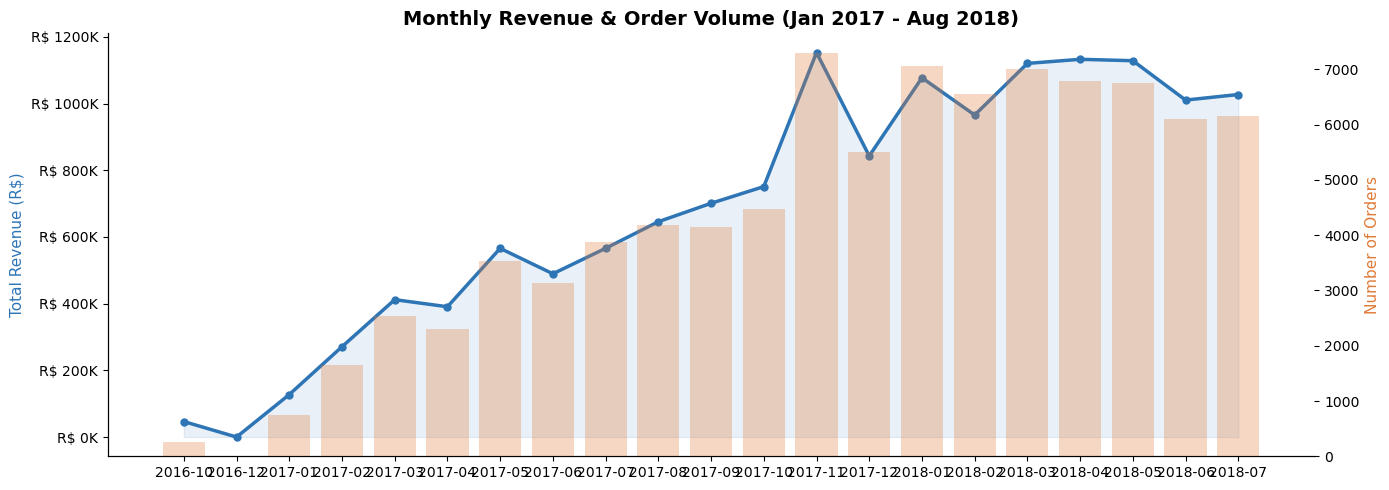

Chart 1 saved.


In [4]:
# Cell 2: Monthly Revenue Trend
monthly = (df.groupby('order_yearmonth')
 .agg(revenue=('total_item_value','sum'),
 orders=('order_id','nunique'))
 .reset_index()
 .sort_values('order_yearmonth'))
# Remove first and last month (incomplete data)
monthly = monthly.iloc[1:-1]
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly['order_yearmonth'], monthly['revenue'],
 color=BLUE, linewidth=2.5, marker='o', markersize=5, label='Revenue')
ax1.fill_between(monthly['order_yearmonth'], monthly['revenue'],
 alpha=0.1, color=BLUE)
ax1.set_ylabel('Total Revenue (R$)', color=BLUE)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}K'))
ax2 = ax1.twinx()
ax2.bar(monthly['order_yearmonth'], monthly['orders'],
 alpha=0.3, color=ORANGE, label='Orders')
ax2.set_ylabel('Number of Orders', color=ORANGE)
ax1.set_title('Monthly Revenue & Order Volume (Jan 2017 - Aug 2018)')
ax1.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../charts/01_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

#### Chart 2 — Top 10 Product Categories


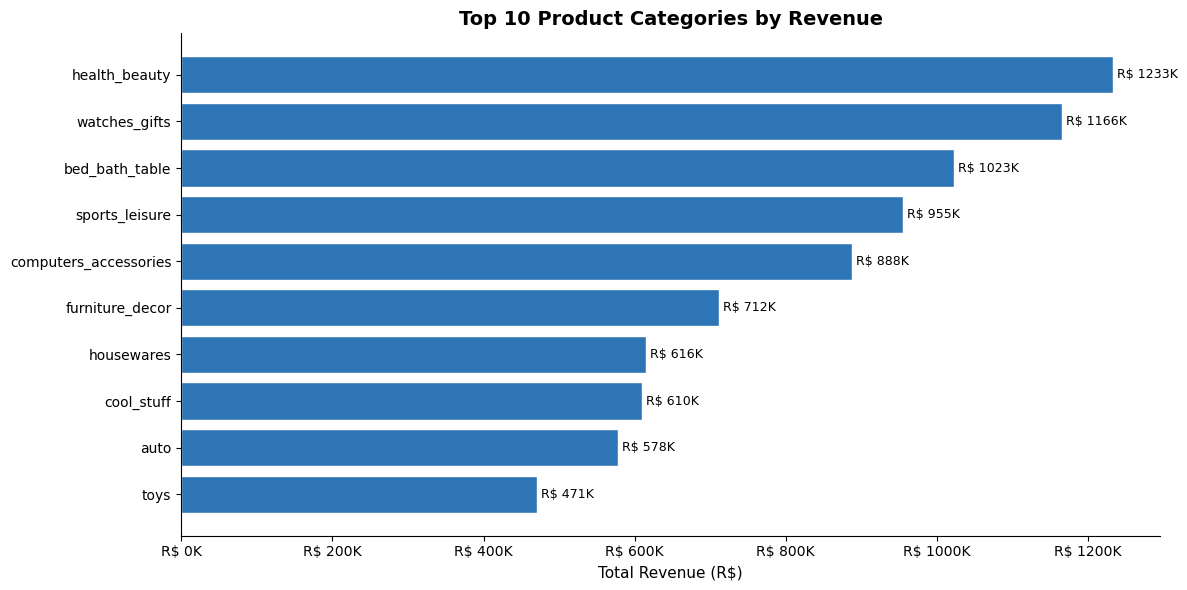

Chart 2 saved.


In [6]:
# Cell 3: Top 10 Categories by Revenue
top_cats = (df.groupby('product_category_name_english')
 .agg(revenue=('price','sum'),
 orders=('order_id','nunique'))
 .reset_index()
 .sort_values('revenue', ascending=False)
 .head(10))
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cats['product_category_name_english'][::-1],
 top_cats['revenue'][::-1],
 color=BLUE, edgecolor='white')
# Add value labels
for bar, val in zip(bars, top_cats['revenue'][::-1]):
 ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
 f'R$ {val/1000:.0f}K', va='center', fontsize=9)
ax.set_title('Top 10 Product Categories by Revenue')
ax.set_xlabel('Total Revenue (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../charts/02_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

#### Chart 3 — Review Score Distribution

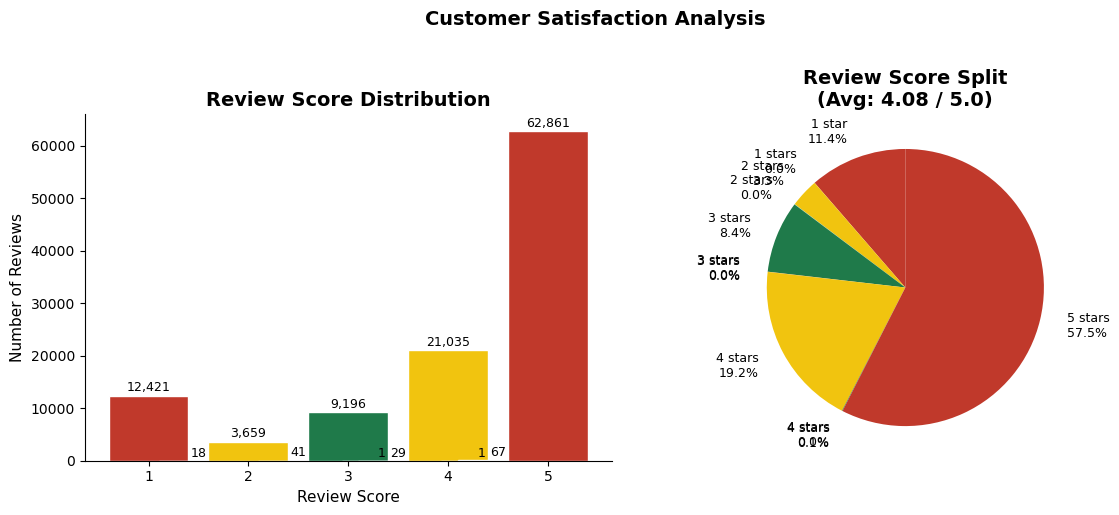

Chart 3 saved.


In [18]:
# Cell 4: Review Score Distribution
score_counts = df['review_score'].value_counts().sort_index()
colors = [RED, ORANGE, '#F1C40F', '#A8D5A2', GREEN][:len(score_counts)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white')
for bar, count in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{count:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1,2,3,4,5])
# Pie chart
total = score_counts.sum()
score_labels = [f'{int(score)} star{"s" if score > 1 else ""}\n{count/total*100:.1f}%' for score, count in score_counts.items()]
axes[1].pie(score_counts.values, labels=score_labels, colors=colors,
 autopct=None, startangle=90, labeldistance=1.2, textprops={'fontsize': 9})
axes[1].set_title('Review Score Split\n(Avg: ' + f'{df["review_score"].mean():.2f}' + ' / 5.0)')
plt.suptitle('Customer Satisfaction Analysis', fontsize=14, fontweight='bold',
y=1.02)
plt.tight_layout()
plt.savefig('../charts/03_review_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

#### Chart 4 — Delivery Performance

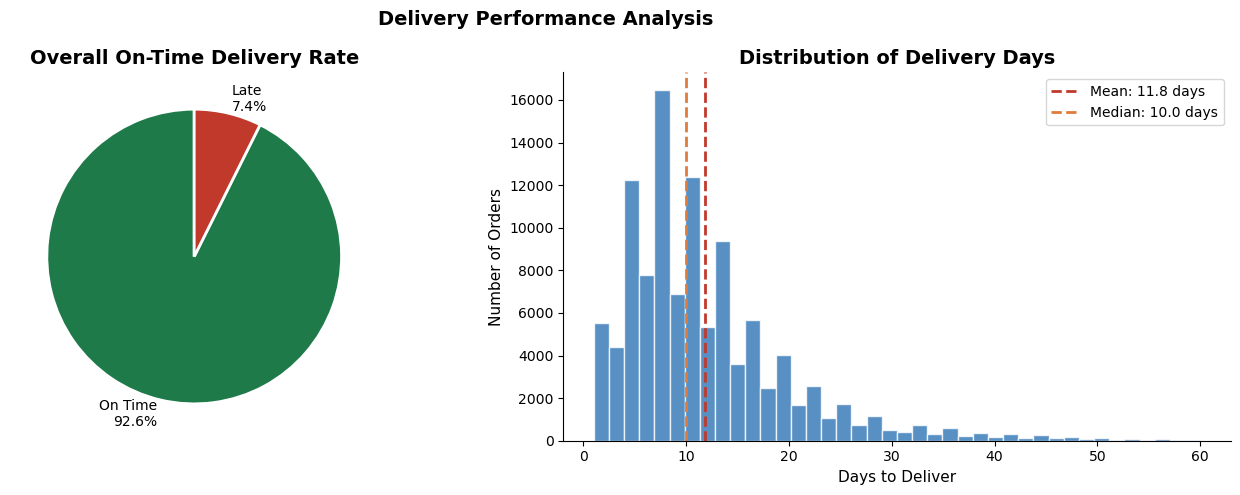

Chart 4 saved.


In [11]:
# Cell 5: Delivery Performance
on_time_rate = df['on_time'].mean() * 100
late_rate = 100 - on_time_rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left: On-time pie chart
axes[0].pie([on_time_rate, late_rate],
 labels=[f'On Time\n{on_time_rate:.1f}%',
f'Late\n{late_rate:.1f}%'],
 colors=[GREEN, RED], startangle=90,
wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall On-Time Delivery Rate')
# Right: Delivery days distribution
del_days = df[df['delivery_days'].between(1, 60)]['delivery_days']
axes[1].hist(del_days, bins=40, color=BLUE, edgecolor='white', alpha=0.8)
axes[1].axvline(del_days.mean(), color=RED, linestyle='--', linewidth=2,
 label=f'Mean: {del_days.mean():.1f} days')
axes[1].axvline(del_days.median(), color=ORANGE, linestyle='--', linewidth=2,
 label=f'Median: {del_days.median():.1f} days')
axes[1].set_title('Distribution of Delivery Days')
axes[1].set_xlabel('Days to Deliver')
axes[1].set_ylabel('Number of Orders')
axes[1].legend()
plt.suptitle('Delivery Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/04_delivery_performance.png', dpi=150,
bbox_inches='tight')
plt.show()
print('Chart 4 saved.')


####  Chart 5 — Revenue by State

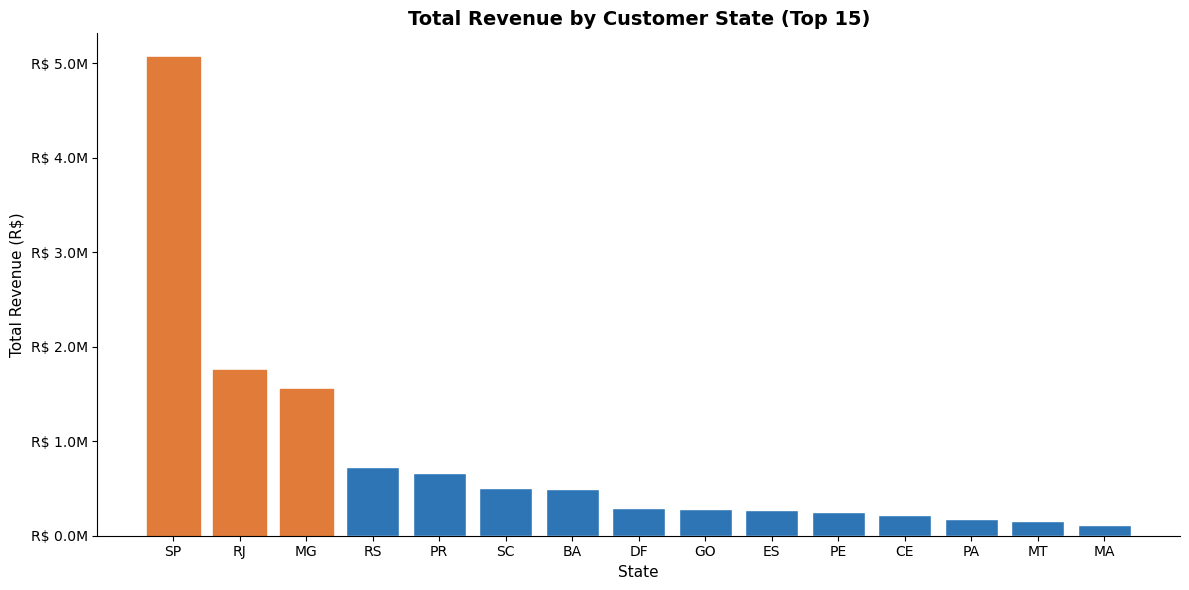

Chart 5 saved.


In [13]:
# Cell 6: Revenue by Customer State
state_rev = (df.groupby('customer_state')
 .agg(revenue=('price','sum'),
 orders=('order_id','nunique'),
avg_score=('review_score','mean'))
 .reset_index()
 .sort_values('revenue', ascending=False)
 .head(15))
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(state_rev['customer_state'], state_rev['revenue'],
 color=BLUE, edgecolor='white')
# Highlight top 3
for i in range(3):
 bars[i].set_color(ORANGE)
ax.set_title('Total Revenue by Customer State (Top 15)')
ax.set_xlabel('State')
ax.set_ylabel('Total Revenue (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../charts/05_revenue_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

#### Chart 6 — Payment Method Breakdown


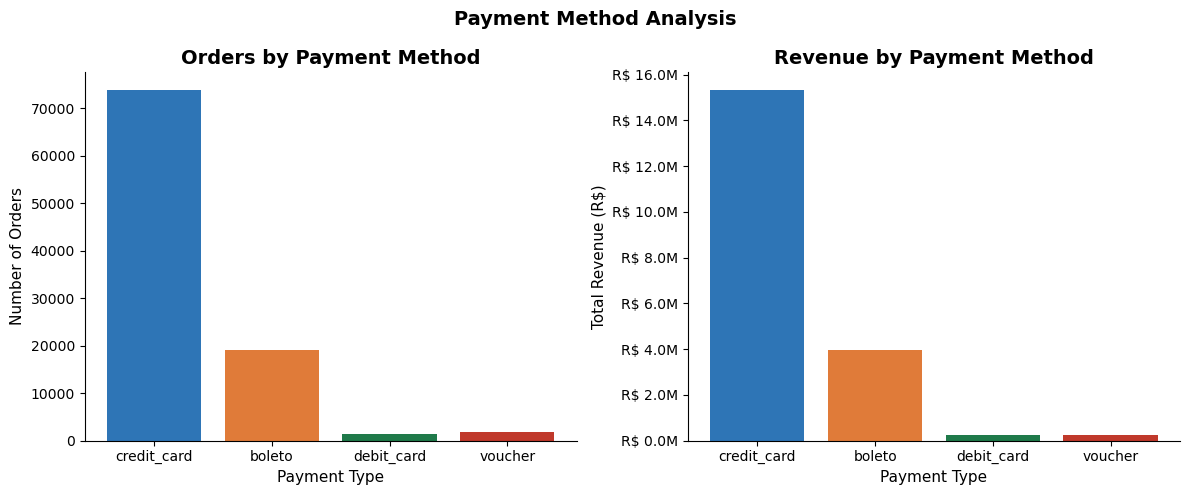

Chart 6 saved.

All 6 charts saved to ../charts/ folder!


In [15]:
# Cell 7: Payment Method Breakdown
pay = df.groupby('payment_type').agg(
 orders=('order_id','nunique'),
 revenue=('payment_value','sum')
).reset_index().sort_values('revenue', ascending=False)
pay = pay[pay['payment_type'] != 'not_defined']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pay_colors = [BLUE, ORANGE, GREEN, RED]
# Orders by payment type
axes[0].bar(pay['payment_type'], pay['orders'], color=pay_colors[:len(pay)])
axes[0].set_title('Orders by Payment Method')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Orders')
# Revenue by payment type
axes[1].bar(pay['payment_type'], pay['revenue'], color=pay_colors[:len(pay)])
axes[1].set_title('Revenue by Payment Method')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
plt.suptitle('Payment Method Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/06_payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')
print()
print('All 6 charts saved to ../charts/ folder!')